In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import time
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from src.data_utils import load_diabetes_data


import sys
sys.path.append('..')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
X, y = load_diabetes_data()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.01, 0.99)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    return scores.mean()

start_time = time.time()
study = optuna.create_study(direction='maximize', study_name='elasticnet_optimization')
study.optimize(objective, n_trials=100, show_progress_bar=True)
optuna_time = time.time() - start_time

print(f"\nOptuna completed in {optuna_time:.2f} seconds")
print(f"Best value: {study.best_value:.4f}")
print(f"Best parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value:.6f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 68. Best value: 0.482328: 100%|██████████| 100/100 [00:04<00:00, 21.71it/s]


Optuna completed in 4.61 seconds
Best value: 0.4823
Best parameters:
  alpha: 0.000513
  l1_ratio: 0.036111


C:\Users\marci\AppData\Local\Temp\ipykernel_3980\4059439143.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


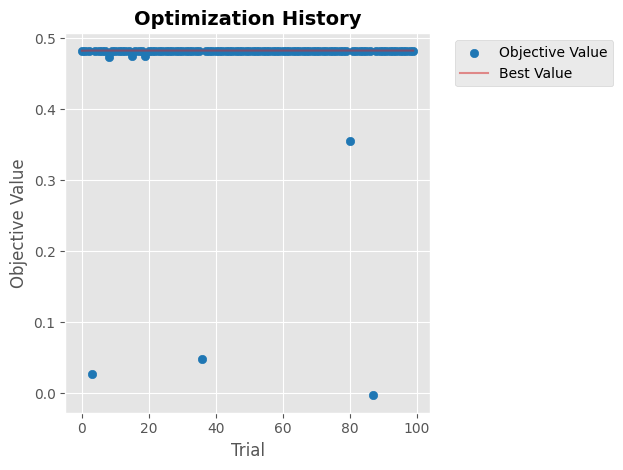

C:\Users\marci\AppData\Local\Temp\ipykernel_3980\4059439143.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


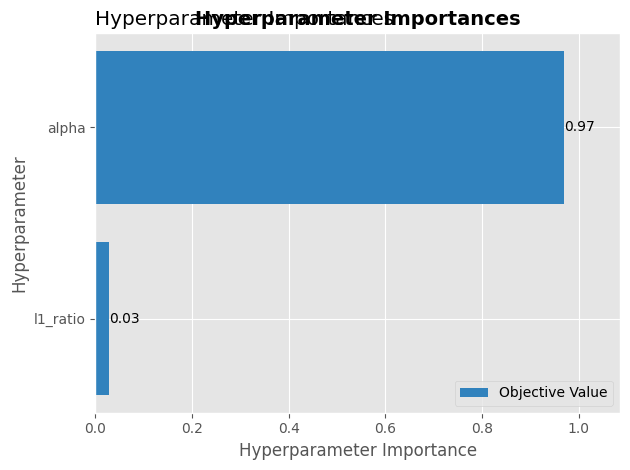

C:\Users\marci\AppData\Local\Temp\ipykernel_3980\4059439143.py:11: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(study, params=['alpha', 'l1_ratio'])


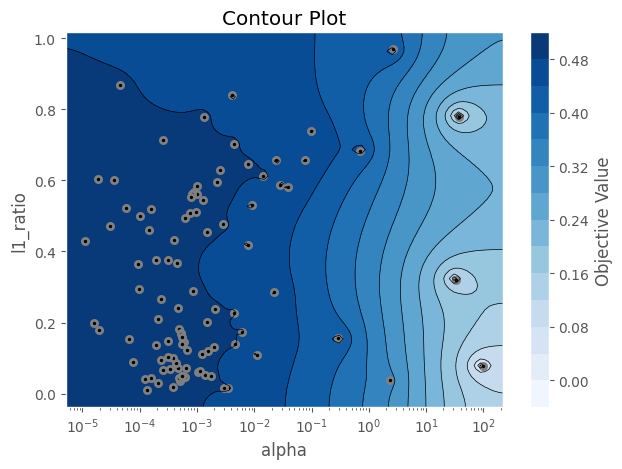

In [10]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optimization History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title('Hyperparameter Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig = optuna.visualization.matplotlib.plot_contour(study, params=['alpha', 'l1_ratio'])
plt.tight_layout()
plt.show()

In [11]:
param_grid = {
    'alpha': np.logspace(-5, 2, 10),
    'l1_ratio': np.linspace(0.01, 0.99, 10)
}

grid_search = GridSearchCV(
    ElasticNet(max_iter=10000, random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_scaled, y)
grid_time = time.time() - start_time

print(f"\nGrid Search completed in {grid_time:.2f} seconds")
print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:")
for key, value in grid_search.best_params_.items():
    print(f"  {key}: {value:.6f}")


Grid Search completed in 0.56 seconds
Best score: 0.4824
Best parameters:
  alpha: 0.077426
  l1_ratio: 0.990000


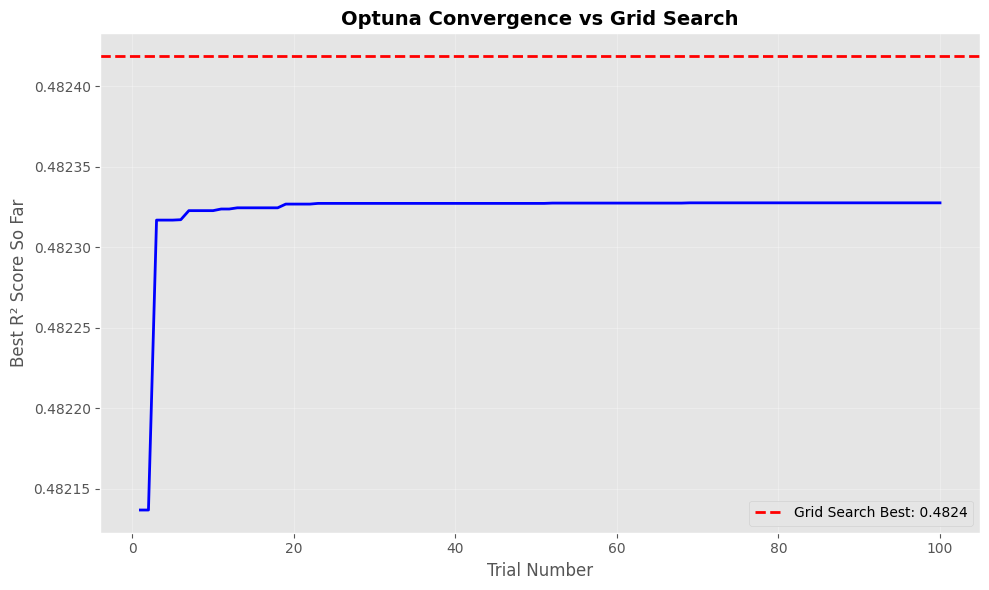

In [12]:
trials_data = []
best_so_far = -np.inf
for i, trial in enumerate(study.trials):
    if trial.value > best_so_far:
        best_so_far = trial.value
    trials_data.append({'trial': i+1, 'best_score': best_so_far})

trials_df = pd.DataFrame(trials_data)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(trials_df['trial'], trials_df['best_score'], linewidth=2, color='blue')
ax.axhline(y=grid_search.best_score_, color='red', linestyle='--', 
           linewidth=2, label=f'Grid Search Best: {grid_search.best_score_:.4f}')
ax.set_xlabel('Trial Number', fontsize=12)
ax.set_ylabel('Best R² Score So Far', fontsize=12)
ax.set_title('Optuna Convergence vs Grid Search', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
def objective_with_pruning(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.01, 0.99)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
        X_train_fold = X_scaled[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X_scaled[val_idx]
        y_val_fold = y[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        score = model.score(X_val_fold, y_val_fold)
        scores.append(score)
        
        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(scores)

pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
study_pruned = optuna.create_study(direction='maximize', pruner=pruner, 
                                   study_name='elasticnet_with_pruning')

start_time = time.time()
study_pruned.optimize(objective_with_pruning, n_trials=200, show_progress_bar=True)
pruned_time = time.time() - start_time

n_pruned = len([t for t in study_pruned.trials if t.state == optuna.trial.TrialState.PRUNED])
n_complete = len([t for t in study_pruned.trials if t.state == optuna.trial.TrialState.COMPLETE])

print(f"\nPruned study completed in {pruned_time:.2f} seconds")
print(f"Complete trials: {n_complete}")
print(f"Pruned trials: {n_pruned} ({n_pruned/200*100:.1f}%)")
print(f"Best value: {study_pruned.best_value:.4f}")
print(f"Best parameters:")
for key, value in study_pruned.best_params.items():
    print(f"  {key}: {value:.6f}")

Best trial: 69. Best value: 0.479763: 100%|██████████| 200/200 [00:06<00:00, 32.41it/s]



Pruned study completed in 6.18 seconds
Complete trials: 182
Pruned trials: 18 (9.0%)
Best value: 0.4798
Best parameters:
  alpha: 0.405625
  l1_ratio: 0.935915


In [15]:
unpruned_200_time = optuna_time * 2
efficiency_gain = (unpruned_200_time - pruned_time) / unpruned_200_time * 100

print(f"\nEfficiency comparison:")
print(f"  Estimated time for 200 unpruned trials: {unpruned_200_time:.2f}s")
print(f"  Actual time for 200 pruned trials: {pruned_time:.2f}s")
print(f"  Time savings: {efficiency_gain:.1f}%")

comparison_data = {
    'Method': ['Optuna (100 trials)', 'Grid Search (100 combinations)', 
               'Optuna with Pruning (200 trials)'],
    'Best Score': [study.best_value, grid_search.best_score_, study_pruned.best_value],
    'Time (seconds)': [optuna_time, grid_time, pruned_time],
    'Alpha': [study.best_params['alpha'], grid_search.best_params_['alpha'], 
              study_pruned.best_params['alpha']],
    'L1 Ratio': [study.best_params['l1_ratio'], grid_search.best_params_['l1_ratio'],
                 study_pruned.best_params['l1_ratio']]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Efficiency comparison:
  Estimated time for 200 unpruned trials: 9.22s
  Actual time for 200 pruned trials: 6.18s
  Time savings: 33.0%
                          Method  Best Score  Time (seconds)    Alpha  L1 Ratio
             Optuna (100 trials)    0.482328        4.610551 0.000513  0.036111
  Grid Search (100 combinations)    0.482419        0.557416 0.077426  0.990000
Optuna with Pruning (200 trials)    0.479763        6.176955 0.405625  0.935915


1. Similar performance: 0.4823 vs 0.4824. Both methods are effective for this problem

2. For this problem grid search was much faster but it can depend on parallelization settings

3. Based on parameter importance plot $\alpha$ is way more important

4. Pruning allowed exploring 2 times more trials in 2 seconds less and didn't produce much worse score